# Ames Housing Price Prediction with Feature Engineering and Regression Pipelines

## Objective
Develop a robust machine learning pipeline to predict residential sale prices in Ames, Iowa, using structured housing data, feature engineering, and regression model comparison.

## Project Overview
This project explores the Ames Housing dataset, a rich structured dataset containing detailed property attributes for residential homes. The goal is to build and evaluate regression models capable of accurately predicting house sale prices while demonstrating strong preprocessing, feature engineering, and model interpretation practices.

## Workflow
1. Load and inspect the dataset
2. Explore missing values and feature structure
3. Analyze the target variable and key predictors
4. Engineer meaningful housing-related features
5. Build preprocessing pipelines for numeric and categorical variables
6. Train and compare multiple regression models
7. Evaluate performance using RMSE, MAE, and R²
8. Interpret the best-performing model and summarize findings

In [2]:
# ============================================
# Block 1 — Imports and Configuration
# ============================================

# Core libraries
import warnings
import os
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Scikit-learn: preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Scikit-learn: models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Scikit-learn: metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Notebook display options
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Plot styling
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Paths for Google Drive project structure
PROJECT_ROOT = Path("/content/drive/MyDrive/ML Portfolio/ames-housing-price-prediction")
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

# Ensure figures directory exists
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory exists:", DATA_DIR.exists())
print("Figures directory exists:", FIGURES_DIR.exists())
print("Notebooks directory exists:", NOTEBOOKS_DIR.exists())

Project root: /content/drive/MyDrive/ML Portfolio/ames-housing-price-prediction
Data directory exists: True
Figures directory exists: True
Notebooks directory exists: True


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Block 2 — Load Dataset

In this section, we load the Ames Housing training and test datasets, inspect their dimensions, and preview their structure. The training dataset contains the target variable `SalePrice`, while the test dataset is used only for unseen prediction in the original Kaggle competition setting.

At this stage, the focus is on:
- confirming successful data loading
- checking dataset size
- previewing the first rows
- identifying the target variable
- understanding the difference between training and test data

### Loading Training and Test Data

In [3]:
# ============================================
# Block 2 — Load Dataset
# ============================================

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
sample_submission_path = DATA_DIR / "sample_submission.csv"
data_description_path = DATA_DIR / "data_description.txt"

# Load datasets
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
df_submission = pd.read_csv(sample_submission_path)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print("Sample submission shape:", df_submission.shape)

print("\nTrain columns preview:")
print(df_train.columns.tolist()[:10], "...")

print("\nTarget column present in training data:", "SalePrice" in df_train.columns)
print("Target column present in test data:", "SalePrice" in df_test.columns)

Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)

Train columns preview:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities'] ...

Target column present in training data: True
Target column present in test data: False


In [4]:
# Preview the training dataset
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.000",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.000",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.000",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.000",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.000",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Preview the test dataset
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.000,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,CBlock,TA,TA,No,Rec,468.000,LwQ,144.000,270.000,882.000,GasA,TA,Y,SBrkr,896,0,0,896,0.000,0.000,1,0,2,1,TA,5,Typ,0,NaN,Attchd,"1,961.000",Unf,1.000,730.000,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.000,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.000,TA,TA,CBlock,TA,TA,No,ALQ,923.000,Unf,0.000,406.000,"1,329.000",GasA,TA,Y,SBrkr,1329,0,0,1329,0.000,0.000,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,"1,958.000",Unf,1.000,312.000,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.000,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,PConc,Gd,TA,No,GLQ,791.000,Unf,0.000,137.000,928.000,GasA,Gd,Y,SBrkr,928,701,0,1629,0.000,0.000,2,1,3,1,TA,6,Typ,1,TA,Attchd,"1,997.000",Fin,2.000,482.000,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.000,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.000,TA,TA,PConc,TA,TA,No,GLQ,602.000,Unf,0.000,324.000,926.000,GasA,Ex,Y,SBrkr,926,678,0,1604,0.000,0.000,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,"1,998.000",Fin,2.000,470.000,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.000,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.000,Gd,TA,PConc,Gd,TA,No,ALQ,263.000,Unf,0.000,"1,017.000","1,280.000",GasA,Ex,Y,SBrkr,1280,0,0,1280,0.000,0.000,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,"1,992.000",RFn,2.000,506.000,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [6]:
# Quick summary of dataset roles
dataset_summary = pd.DataFrame({
    "Dataset": ["Training Set", "Test Set", "Sample Submission"],
    "Rows": [df_train.shape[0], df_test.shape[0], df_submission.shape[0]],
    "Columns": [df_train.shape[1], df_test.shape[1], df_submission.shape[1]],
    "Contains SalePrice": [
        "SalePrice" in df_train.columns,
        "SalePrice" in df_test.columns,
        "SalePrice" in df_submission.columns
    ]
})

dataset_summary

,Dataset,Rows,Columns,Contains SalePrice
0,Training Set,1460,81,True
1,Test Set,1459,80,False
2,Sample Submission,1459,2,True


### Dataset Structure Observations

The Ames Housing dataset contains **1460 observations with 81 variables** in the training set and **1459 observations with 80 variables** in the test set.

Key observations:

- The **target variable `SalePrice` is present only in the training dataset**, which is expected since the test dataset is intended for prediction.
- The feature structure between the training and test sets is nearly identical, enabling the same preprocessing pipeline to be applied to both datasets.
- The dataset contains a **large number of explanatory variables**, including:
  - structural house characteristics
  - property size metrics
  - construction quality indicators
  - neighborhood and location information
  - garage, basement, and exterior attributes

This rich feature space makes the dataset particularly suitable for **feature engineering and regression modeling**.

## Block 3 — Initial Data Inspection

Before performing detailed exploratory analysis, we conduct an initial inspection of the dataset to understand its structure and overall characteristics.

This step focuses on:

- inspecting data types
- identifying potential duplicate rows
- examining summary statistics
- checking the distribution of the target variable

Understanding the dataset structure early helps guide subsequent preprocessing and feature engineering steps.

In [7]:
# ============================================
# Block 3 — Initial Data Inspection
# ============================================

print("Training dataset shape:", df_train.shape)
print("Test dataset shape:", df_test.shape)

Training dataset shape: (1460, 81)
Test dataset shape: (1459, 80)


### Dataset Structure and Data Types

We first inspect the structure of the training dataset to understand the number of features, their data types, and the presence of missing values. This provides an initial overview of the dataset and helps identify variables that may require preprocessing.

In [8]:
# Dataset information
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [9]:
# Separate numeric and categorical columns
numeric_features = df_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = df_train.select_dtypes(include=["object"]).columns

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))
print("Total features:", len(df_train.columns))

Number of numeric features: 38
Number of categorical features: 43
Total features: 81


In [10]:
# Preview numeric features
numeric_features[:15]

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF'],
      dtype='object')

In [12]:
# Preview categorical features
categorical_features[:15]

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl'],
      dtype='object')

In [11]:
# Check for duplicate rows
duplicate_rows = df_train.duplicated().sum()

print("Number of duplicate rows in training dataset:", duplicate_rows)

Number of duplicate rows in training dataset: 0


In [14]:
# Summary statistics for numeric features
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,"1,460.000","1,460.000","1,201.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,452.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,379.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000","1,460.000"
mean,730.500,56.897,70.050,"10,516.828",6.099,5.575,"1,971.268","1,984.866",103.685,443.640,46.549,567.240,"1,057.429","1,162.627",346.992,5.845,"1,515.464",0.425,0.058,1.565,0.383,2.866,1.047,6.518,0.613,"1,978.506",1.767,472.980,94.245,46.660,21.954,3.410,15.061,2.759,43.489,6.322,"2,007.816","180,921.196"
std,421.610,42.301,24.285,"9,981.265",1.383,1.113,30.203,20.645,181.066,456.098,161.319,441.867,438.705,386.588,436.528,48.623,525.480,0.519,0.239,0.551,0.503,0.816,0.220,1.625,0.645,24.690,0.747,213.805,125.339,66.256,61.119,29.317,55.757,40.177,496.123,2.704,1.328,"79,442.503"
min,1.000,20.000,21.000,"1,300.000",1.000,1.000,"1,872.000","1,950.000",0.000,0.000,0.000,0.000,0.000,334.000,0.000,0.000,334.000,0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,"1,900.000",0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,"2,006.000","34,900.000"
25%,365.750,20.000,59.000,"7,553.500",5.000,5.000,"1,954.000","1,967.000",0.000,0.000,0.000,223.000,795.750,882.000,0.000,0.000,"1,129.500",0.000,0.000,1.000,0.000,2.000,1.000,5.000,0.000,"1,961.000",1.000,334.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.000,"2,007.000","129,975.000"
50%,730.500,50.000,69.000,"9,478.500",6.000,5.000,"1,973.000","1,994.000",0.000,383.500,0.000,477.500,991.500,"1,087.000",0.000,0.000,"1,464.000",0.000,0.000,2.000,0.000,3.000,1.000,6.000,1.000,"1,980.000",2.000,480.000,0.000,25.000,0.000,0.000,0.000,0.000,0.000,6.000,"2,008.000","163,000.000"
75%,"1,095.250",70.000,80.000,"11,601.500",7.000,6.000,"2,000.000","2,004.000",166.000,712.250,0.000,808.000,"1,298.250","1,391.250",728.000,0.000,"1,776.750",1.000,0.000,2.000,1.000,3.000,1.000,7.000,1.000,"2,002.000",2.000,576.000,168.000,68.000,0.000,0.000,0.000,0.000,0.000,8.000,"2,009.000","214,000.000"
max,"1,460.000",190.000,313.000,"215,245.000",10.000,9.000,"2,010.000","2,010.000","1,600.000","5,644.000","1,474.000","2,336.000","6,110.000","4,692.000","2,065.000",572.000,"5,642.000",3.000,2.000,3.000,2.000,8.000,3.000,14.000,3.000,"2,010.000",4.000,"1,418.000",857.000,547.000,552.000,508.000,480.000,738.000,"15,500.000",12.000,"2,010.000","755,000.000"


In [13]:
# Summary statistics for categorical features
df_train.describe(include="object")

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,588,1460,1460,1460,1423,1423,1422,1423,1422,1460,1460,1460,1459,1460,1460,770,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,8,5,8,6,8,15,16,3,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,1141,1434,515,504,445,906,1282,647,649,1311,953,430,1256,1428,741,1365,1334,735,1360,380,870,605,1311,1326,1340,3,157,49,1267,1198


In [15]:
# Basic statistics for the target variable
df_train["SalePrice"].describe()

,SalePrice
count,"1,460.000"
mean,"180,921.196"
std,"79,442.503"
min,"34,900.000"
25%,"129,975.000"
50%,"163,000.000"
75%,"214,000.000"
max,"755,000.000"


In [16]:
# Check skewness of SalePrice
df_train["SalePrice"].skew()

np.float64(1.8828757597682129)

### Target Distribution Insight

The target variable `SalePrice` exhibits **positive skewness**, meaning that a small number of high-priced homes create a long right tail in the distribution.

For many regression algorithms, modeling the **log-transformed target variable** often improves performance and stabilizes variance. Later in the analysis we will examine the distribution of the log-transformed target to determine whether this transformation is beneficial.

### Initial Observations

The dataset contains **1460 observations and 81 variables** in the training set, including the target variable `SalePrice`.

Key structural characteristics of the dataset:

- The data includes **38 numeric features and 43 categorical features**, representing property characteristics, structural attributes, and neighborhood information.
- Several variables contain **missing values**, particularly features related to basements, garages, masonry veneer, and exterior property attributes.
- Some features (e.g., `Alley`, `PoolQC`, `Fence`, `MiscFeature`) contain **very large proportions of missing values**, which may indicate that the corresponding feature simply does not exist for many properties.
- The dataset includes **no duplicate observations**, suggesting the records represent unique housing transactions.

The target variable `SalePrice` shows substantial variation across properties, indicating that a predictive model will need to capture both structural and locational influences on housing prices.

## Block 4 — Missing Values Analysis

Real-world datasets frequently contain missing values that must be handled before training machine learning models. Understanding the extent and structure of missing data is essential for designing an effective preprocessing strategy.

In this section we:

- identify features containing missing values
- quantify the percentage of missing data for each feature
- visualize the most affected variables
- examine patterns that may indicate structural missingness (e.g., absence of a feature such as a garage or pool)

This analysis will guide our imputation strategy later in the modeling pipeline.

In [17]:
# ============================================
# Block 4 — Missing Values Analysis
# ============================================

# Calculate missing values
missing_counts = df_train.isnull().sum()

missing_percent = (missing_counts / len(df_train)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_counts,
    "Percentage (%)": missing_percent
})

# Keep only columns with missing values
missing_table = missing_table[missing_table["Missing Values"] > 0]

# Sort by percentage
missing_table = missing_table.sort_values("Percentage (%)", ascending=False)

missing_table

,Missing Values,Percentage (%)
PoolQC,1453,99.521
MiscFeature,1406,96.301
Alley,1369,93.767
Fence,1179,80.753
MasVnrType,872,59.726
FireplaceQu,690,47.260
LotFrontage,259,17.740
GarageType,81,5.548
GarageYrBlt,81,5.548
GarageFinish,81,5.548


In [18]:
# Top 15 features with the most missing values
missing_table.head(15)

,Missing Values,Percentage (%)
PoolQC,1453,99.521
MiscFeature,1406,96.301
Alley,1369,93.767
Fence,1179,80.753
MasVnrType,872,59.726
FireplaceQu,690,47.260
LotFrontage,259,17.740
GarageType,81,5.548
GarageYrBlt,81,5.548
GarageFinish,81,5.548


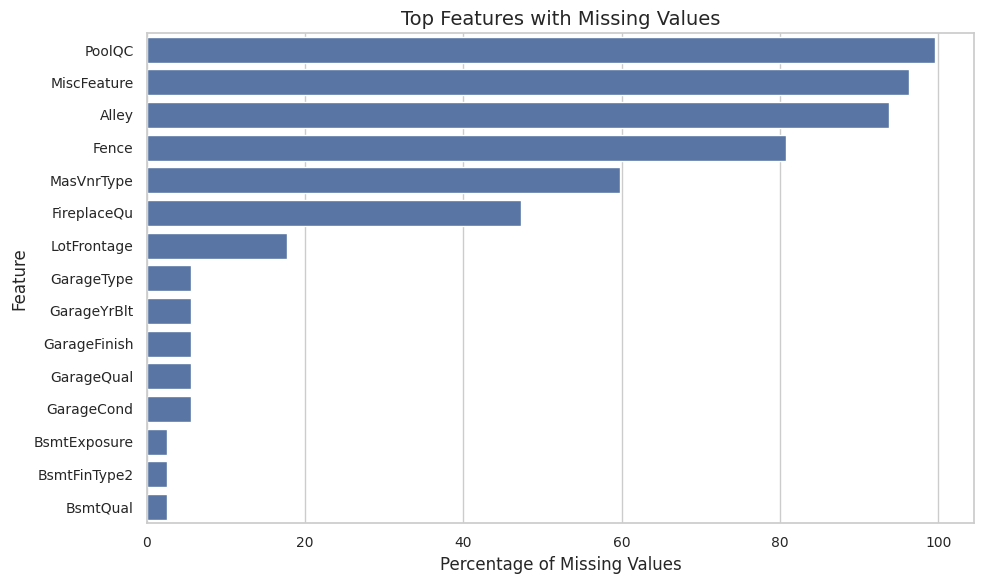

In [19]:
# Plot missing value percentages for top features

top_missing = missing_table.head(15)

plt.figure()

sns.barplot(
    x=top_missing["Percentage (%)"],
    y=top_missing.index
)

plt.title("Top Features with Missing Values")
plt.xlabel("Percentage of Missing Values")
plt.ylabel("Feature")

plt.tight_layout()

# Save figure
plt.savefig(FIGURES_DIR / "missing_values_top_features.png", dpi=300)

plt.show()

In [20]:
print("Number of features with missing values:", missing_table.shape[0])

Number of features with missing values: 19


In [21]:
# Overall missing data proportion

total_missing = df_train.isnull().sum().sum()

total_cells = np.prod(df_train.shape)

missing_ratio = total_missing / total_cells * 100

print(f"Total missing values in dataset: {total_missing}")
print(f"Percentage of missing data in dataset: {missing_ratio:.2f}%")

Total missing values in dataset: 7829
Percentage of missing data in dataset: 6.62%


### Missing Data Observations

The Ames Housing dataset contains **19 features with missing values**, totaling **7,829 missing entries**, which represents approximately **6.62% of the dataset**.

Although several variables contain missing values, the majority of missingness is **structural rather than random**.

Some features exhibit extremely high missing proportions:

- `PoolQC` (~99%)
- `MiscFeature` (~96%)
- `Alley` (~94%)
- `Fence` (~81%)

In many cases, missing values indicate that the feature **does not exist for a particular property** rather than representing absent measurements.

Examples include:

- Missing values in **garage-related features** often indicate houses **without garages**.
- Missing values in **basement-related variables** correspond to houses **without basements**.
- Missing values in **pool-related variables** typically indicate that the property **does not have a pool**.

This suggests that missing values frequently encode **meaningful information about property characteristics**.

During preprocessing we will apply **feature-specific imputation strategies** that preserve this information while preparing the data for machine learning models.

## Block 5 — Target Variable Analysis

The target variable of this project is `SalePrice`, representing the final sale price of residential properties.

Understanding the distribution of the target variable is important because many machine learning algorithms assume approximately normally distributed errors.

In this section we:

- examine the distribution of `SalePrice`
- visualize the skewness of the target variable
- analyze the effect of applying a logarithmic transformation

Log-transforming house prices is a common technique in real estate modeling because property prices typically exhibit **right-skewed distributions**.

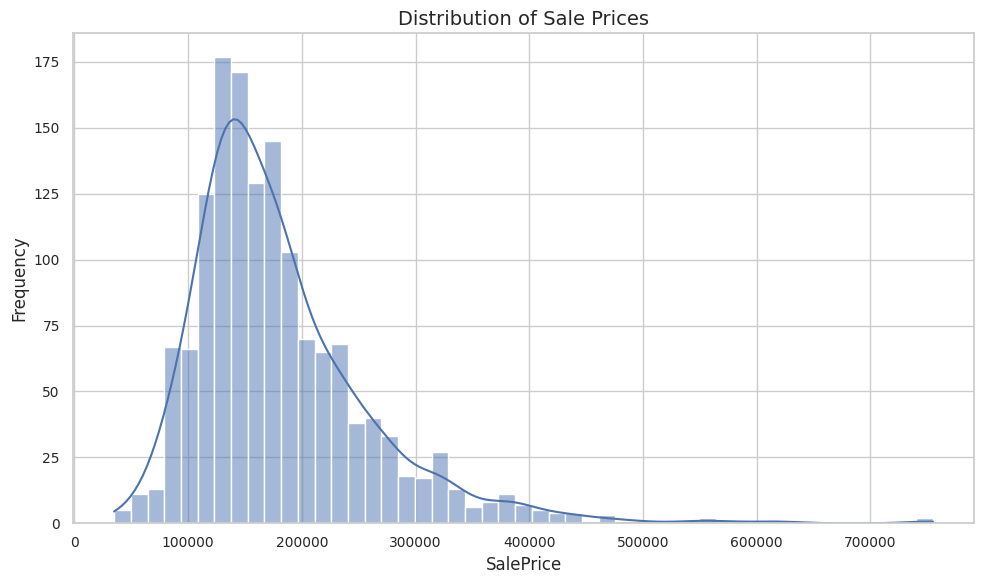

In [22]:
# ============================================
# Block 5 — Target Variable Analysis
# ============================================

plt.figure()

sns.histplot(df_train["SalePrice"], kde=True)

plt.title("Distribution of Sale Prices")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")

plt.tight_layout()

# Save figure
plt.savefig(FIGURES_DIR / "saleprice_distribution.png", dpi=300)

plt.show()

In [23]:
# Log-transform the target variable
df_train["LogSalePrice"] = np.log1p(df_train["SalePrice"])

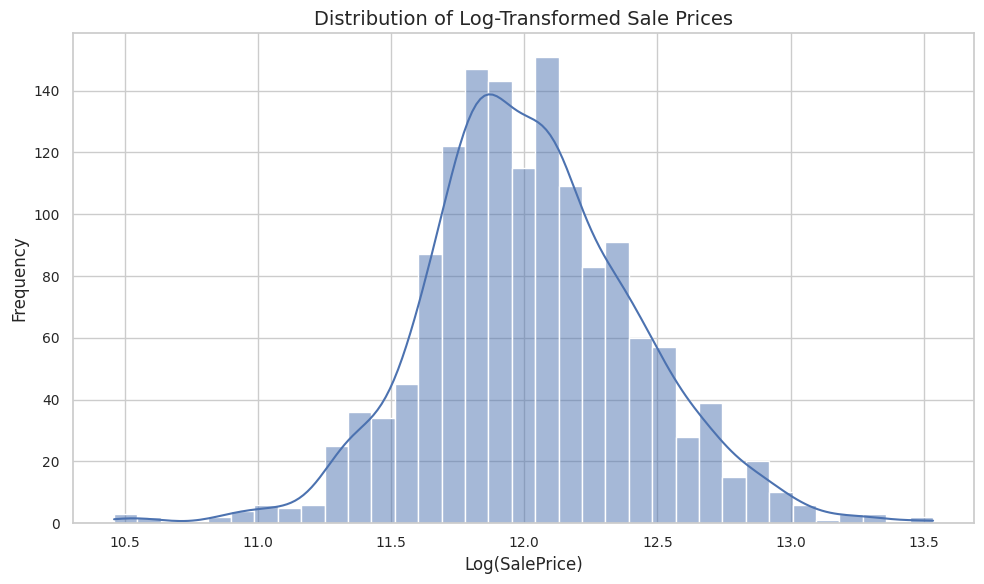

In [24]:
plt.figure()

sns.histplot(df_train["LogSalePrice"], kde=True)

plt.title("Distribution of Log-Transformed Sale Prices")
plt.xlabel("Log(SalePrice)")
plt.ylabel("Frequency")

plt.tight_layout()

# Save figure
plt.savefig(FIGURES_DIR / "log_saleprice_distribution.png", dpi=300)

plt.show()

In [25]:
print("Original SalePrice skewness:", df_train["SalePrice"].skew())
print("Log-transformed SalePrice skewness:", df_train["LogSalePrice"].skew())

Original SalePrice skewness: 1.8828757597682129
Log-transformed SalePrice skewness: 0.12134661989685333


### Target Distribution Observations

The distribution of the target variable `SalePrice` exhibits **strong positive skewness** (skewness ≈ **1.88**), indicating that a relatively small number of high-priced properties create a long right tail in the distribution.

Such skewness can negatively affect regression models because extreme values may exert disproportionate influence during model training.

After applying a **logarithmic transformation** using `log(1 + SalePrice)`, the distribution becomes substantially more symmetric. The skewness decreases dramatically from **1.88 to approximately 0.12**, indicating that the transformed variable is much closer to a normal distribution.

Because many regression algorithms perform better when the target variable is approximately normally distributed, the **log-transformed target (`LogSalePrice`) will be used for model training** in the subsequent modeling stages.

## Block 6 — Numerical Feature Exploration

In this section we explore relationships between numerical features and house prices. Identifying strong predictors early helps guide feature engineering and model design.

We will:

- compute correlations between numeric variables and `SalePrice`
- identify the strongest predictors of housing prices
- visualize key relationships using scatter plots and box plots

This step helps uncover the structural characteristics that most strongly influence residential property values.

In [26]:
# ============================================
# Block 6 — Numerical Feature Exploration
# ============================================

# Correlation of numeric features with SalePrice
correlations = df_train[numeric_features].corr()["SalePrice"].sort_values(ascending=False)

correlations.head(15)

,SalePrice
SalePrice,1.000
OverallQual,0.791
GrLivArea,0.709
GarageCars,0.640
GarageArea,0.623
TotalBsmtSF,0.614
1stFlrSF,0.606
FullBath,0.561
TotRmsAbvGrd,0.534
YearBuilt,0.523


In [27]:
top_corr_features = correlations.head(10).index

top_corr_features

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt'],
      dtype='object')

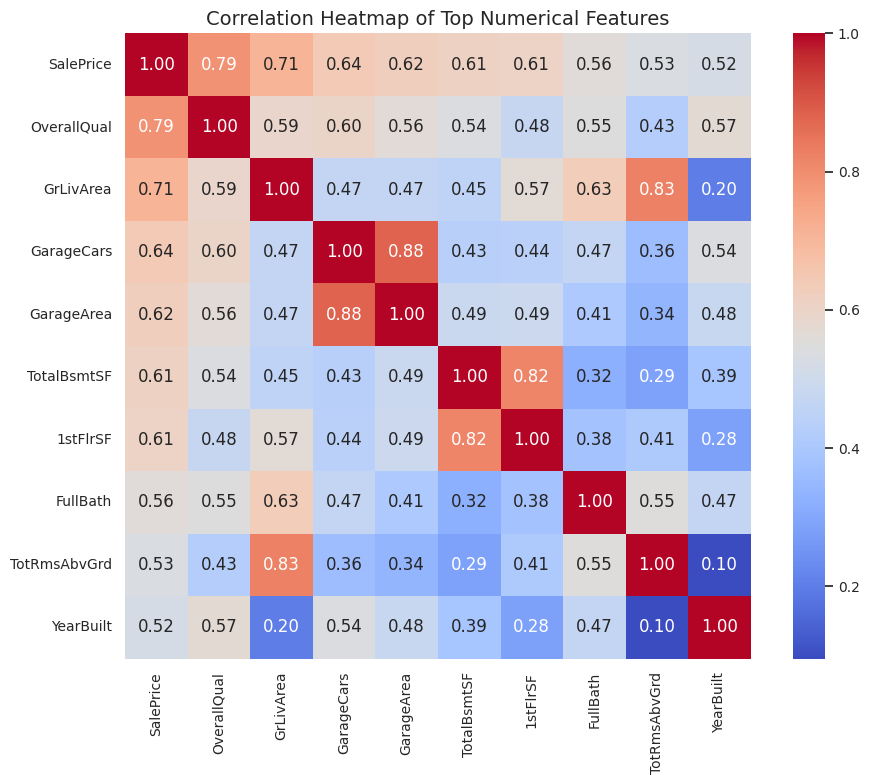

In [28]:
plt.figure(figsize=(10,8))

corr_matrix = df_train[top_corr_features].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Heatmap of Top Numerical Features")

plt.tight_layout()

# Save figure
plt.savefig(FIGURES_DIR / "correlation_heatmap_top_features.png", dpi=300)

plt.show()

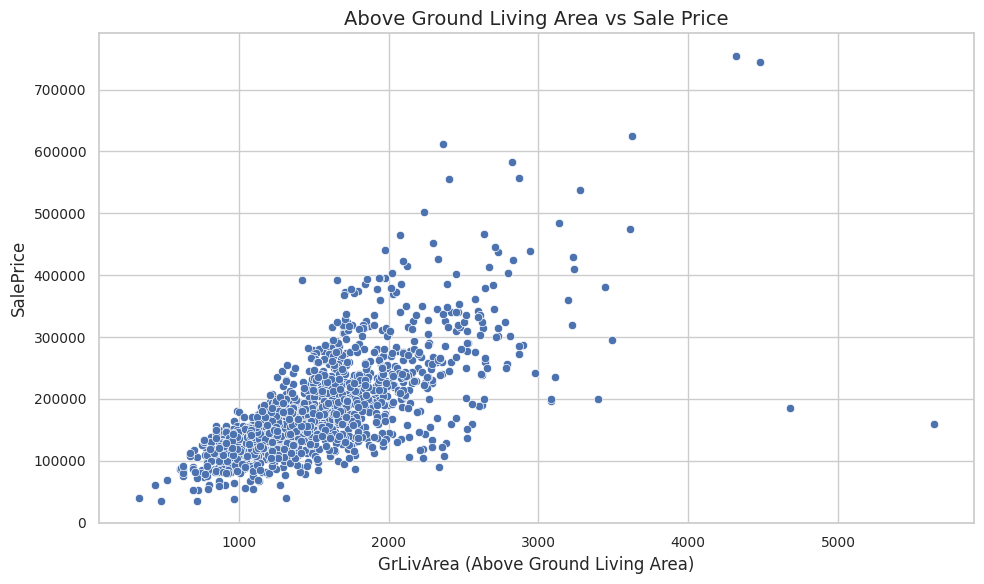

In [29]:
plt.figure()

sns.scatterplot(
    x=df_train["GrLivArea"],
    y=df_train["SalePrice"]
)

plt.title("Above Ground Living Area vs Sale Price")
plt.xlabel("GrLivArea (Above Ground Living Area)")
plt.ylabel("SalePrice")

plt.tight_layout()

# Save figure
plt.savefig(FIGURES_DIR / "grlivarea_vs_saleprice.png", dpi=300)

plt.show()

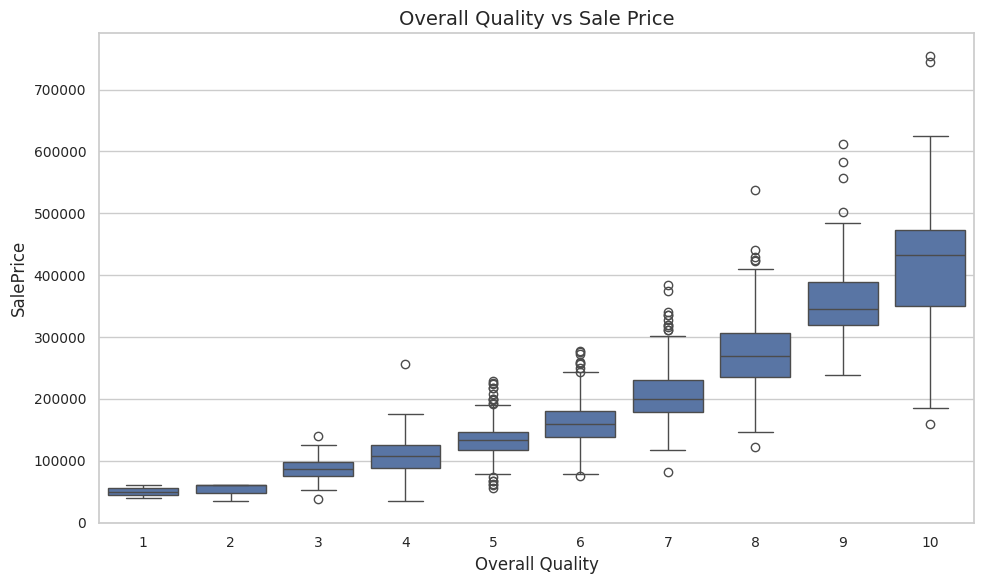

In [30]:
plt.figure()

sns.boxplot(
    x=df_train["OverallQual"],
    y=df_train["SalePrice"]
)

plt.title("Overall Quality vs Sale Price")
plt.xlabel("Overall Quality")
plt.ylabel("SalePrice")

plt.tight_layout()

# Save figure
plt.savefig(FIGURES_DIR / "overallqual_vs_saleprice.png", dpi=300)

plt.show()

### Key Numerical Feature Insights

Correlation analysis reveals several numerical features strongly associated with housing prices.

The most influential predictors include:

- **OverallQual** (correlation ≈ **0.79**) — overall material and finish quality of the house
- **GrLivArea** (≈ **0.71**) — above-ground living area
- **GarageCars** (≈ **0.64**) — garage capacity
- **GarageArea** (≈ **0.62**) — garage size
- **TotalBsmtSF** (≈ **0.61**) — total basement area
- **1stFlrSF** (≈ **0.61**) — first floor living area

The scatter plot of **GrLivArea vs SalePrice** shows a clear positive relationship: larger homes generally command higher market prices.

The box plot of **OverallQual vs SalePrice** reveals a strong monotonic pattern — homes with higher construction quality consistently sell for significantly higher prices.

These findings indicate that **construction quality, living space, and garage capacity are among the strongest structural drivers of housing prices** in the Ames dataset.

## Block 7 — Categorical Feature Exploration

In addition to structural property characteristics, categorical features such as **neighborhood**, **house style**, and **sale condition** can significantly influence housing prices.

Categorical variables often capture:

- geographic location
- architectural styles
- transaction circumstances
- property classification

In this section we examine how several important categorical features relate to housing prices, focusing on:

- **Neighborhood** — location-based price differences
- **HouseStyle** — architectural structure of the house
- **SaleCondition** — circumstances of the property sale

In [31]:
# ============================================
# Block 7 — Categorical Feature Exploration
# ============================================

# Average sale price by neighborhood
neighborhood_prices = (
    df_train.groupby("Neighborhood")["SalePrice"]
    .mean()
    .sort_values(ascending=False)
)

neighborhood_prices.head(10)

,SalePrice
Neighborhood,
NoRidge,"335,295.317"
NridgHt,"316,270.623"
StoneBr,"310,499.000"
Timber,"242,247.447"
Veenker,"238,772.727"
Somerst,"225,379.837"
ClearCr,"212,565.429"
Crawfor,"210,624.725"
CollgCr,"197,965.773"


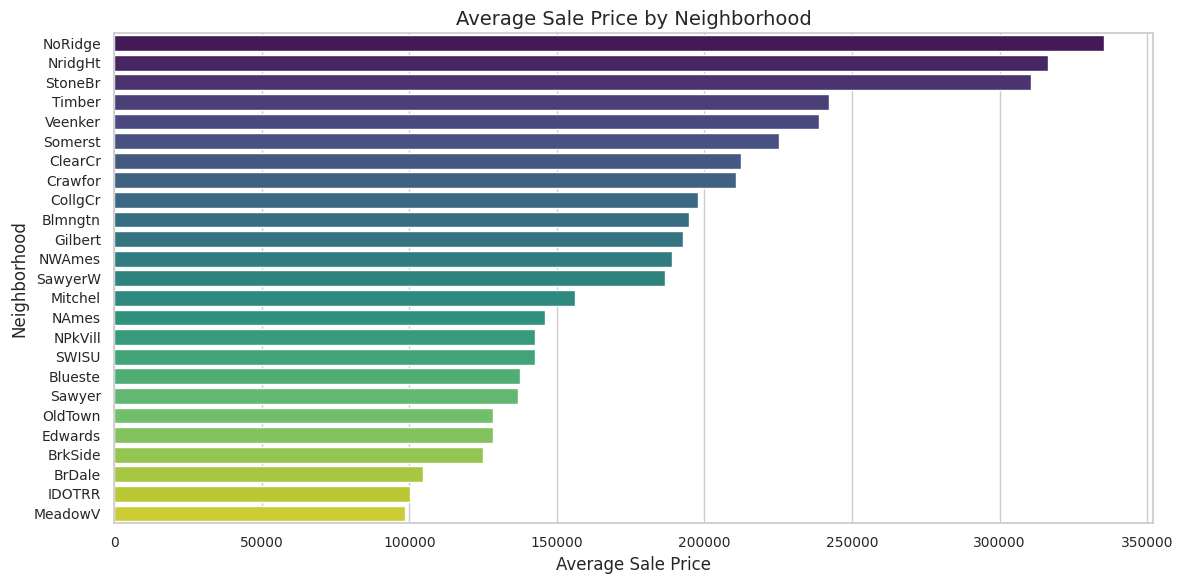

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=neighborhood_prices.values,
    y=neighborhood_prices.index,
    palette="viridis"
)

plt.title("Average Sale Price by Neighborhood")
plt.xlabel("Average Sale Price")
plt.ylabel("Neighborhood")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "average_price_by_neighborhood.png", dpi=300)

plt.show()

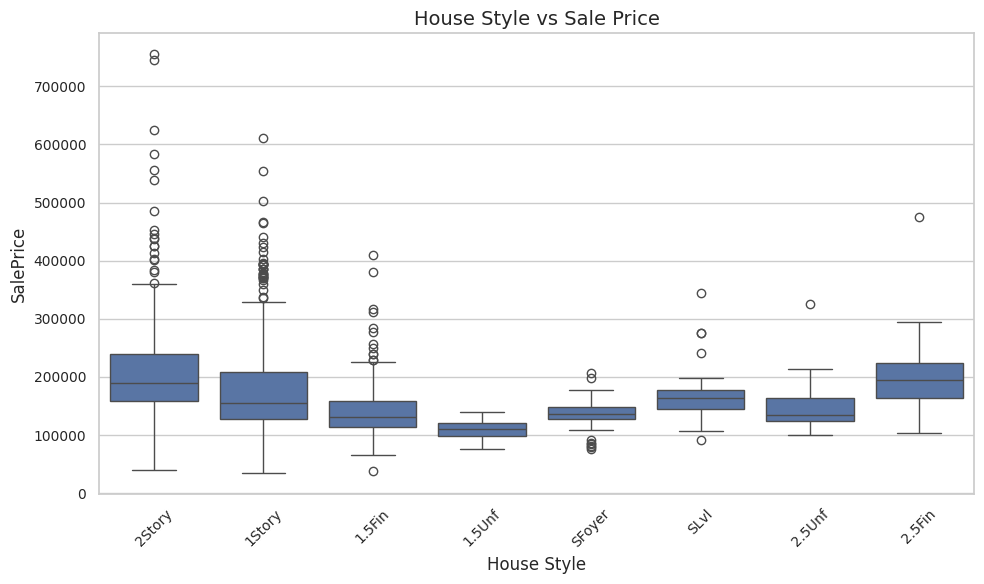

In [33]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df_train["HouseStyle"],
    y=df_train["SalePrice"]
)

plt.title("House Style vs Sale Price")
plt.xlabel("House Style")
plt.ylabel("SalePrice")

plt.xticks(rotation=45)

plt.tight_layout()

# Save figure
plt.savefig(FIGURES_DIR / "housestyle_vs_saleprice.png", dpi=300)

plt.show()

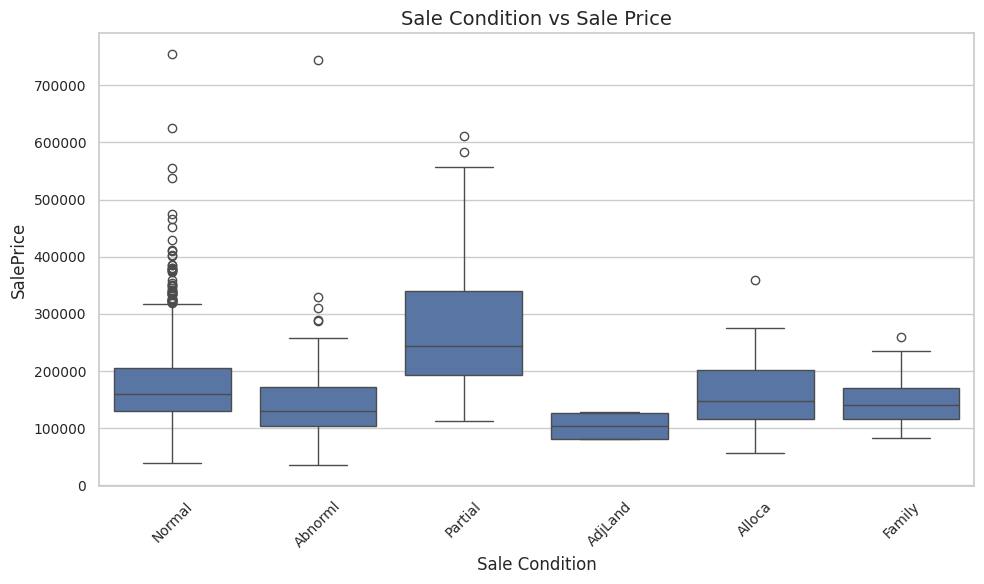

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df_train["SaleCondition"],
    y=df_train["SalePrice"]
)

plt.title("Sale Condition vs Sale Price")
plt.xlabel("Sale Condition")
plt.ylabel("SalePrice")

plt.xticks(rotation=45)

plt.tight_layout()

# Save figure
plt.savefig(FIGURES_DIR / "salecondition_vs_saleprice.png", dpi=300)

plt.show()

### Key Categorical Feature Insights

Categorical features reveal several important patterns in housing prices.

**Neighborhood** shows one of the strongest contextual influences on property values.

Certain neighborhoods command substantially higher average prices. For instance:

- **NoRidge** (~$335k average price)


- **NridgHt** (~$316k)


- **StoneBr** (~$310k)

These neighborhoods represent some of the most desirable residential areas in Ames, reflecting factors such as location quality, neighborhood planning, and housing development standards.

The **HouseStyle** analysis shows variation in prices across architectural structures. Larger multi-story homes generally correspond to higher prices due to greater living area and more complex construction.

The **SaleCondition** feature highlights differences in transaction circumstances. For example, **Partial sales** (often newly constructed homes) tend to exhibit higher prices, while irregular sale conditions may involve discounted transactions.

Overall, these findings demonstrate that **location, structural characteristics, and transaction context all contribute to housing price variation**.

## Block 8 — Feature Engineering

Feature engineering is a critical step in many machine learning projects, particularly when working with structured tabular data.

The Ames Housing dataset contains numerous raw variables describing different aspects of residential properties. By combining these variables and incorporating domain knowledge about housing markets, we can create more informative features for predictive modeling.

In this section we engineer several new features representing:

- **Property age characteristics**
- **Total living space**
- **Total bathroom count**
- **Total porch area**
- **Binary indicators for important property attributes**

These engineered variables help capture meaningful structural and contextual information that may improve model performance.

In [36]:
# ============================================
# Block 8 — Feature Engineering
# ============================================

# House age at time of sale
df_train["HouseAge"] = df_train["YrSold"] - df_train["YearBuilt"]

# Years since last remodel
df_train["RemodAge"] = df_train["YrSold"] - df_train["YearRemodAdd"]

In [37]:
# Total square footage of the house
df_train["TotalSF"] = (
    df_train["TotalBsmtSF"]
    + df_train["1stFlrSF"]
    + df_train["2ndFlrSF"]
)

In [38]:
# Total bathrooms (weighted)
df_train["TotalBathrooms"] = (
    df_train["FullBath"]
    + (0.5 * df_train["HalfBath"])
    + df_train["BsmtFullBath"]
    + (0.5 * df_train["BsmtHalfBath"])
)

In [39]:
# Total porch space
df_train["TotalPorchSF"] = (
    df_train["OpenPorchSF"]
    + df_train["3SsnPorch"]
    + df_train["EnclosedPorch"]
    + df_train["ScreenPorch"]
    + df_train["WoodDeckSF"]
)

In [40]:
# Binary indicators for property features

df_train["HasGarage"] = (df_train["GarageArea"] > 0).astype(int)

df_train["HasBasement"] = (df_train["TotalBsmtSF"] > 0).astype(int)

df_train["HasFireplace"] = (df_train["Fireplaces"] > 0).astype(int)

df_train["HasPool"] = (df_train["PoolArea"] > 0).astype(int)

In [41]:
engineered_features = [
    "HouseAge",
    "RemodAge",
    "TotalSF",
    "TotalBathrooms",
    "TotalPorchSF",
    "HasGarage",
    "HasBasement",
    "HasFireplace",
    "HasPool"
]

df_train[engineered_features].head()

,HouseAge,RemodAge,TotalSF,TotalBathrooms,TotalPorchSF,HasGarage,HasBasement,HasFireplace,HasPool
0,5,5,2566,3.500,61,1,1,0,0
1,31,31,2524,2.500,298,1,1,1,0
2,7,6,2706,3.500,42,1,1,1,0
3,91,36,2473,2.000,307,1,1,1,0
4,8,8,3343,3.500,276,1,1,1,0


In [42]:
df_train[engineered_features + ["SalePrice"]].corr()["SalePrice"].sort_values(ascending=False)

,SalePrice
SalePrice,1.000
TotalSF,0.782
TotalBathrooms,0.632
HasFireplace,0.472
TotalPorchSF,0.391
HasGarage,0.237
HasBasement,0.153
HasPool,0.094
RemodAge,-0.509
HouseAge,-0.523


### Feature Engineering Insights

Several new features were created to better represent structural and contextual characteristics of residential properties.

Correlation analysis shows that some engineered features capture strong predictive signals for housing prices.

Key observations include:

- **TotalSF** shows a strong positive correlation with SalePrice (**≈ 0.78**), indicating that total living space is one of the most important drivers of property value.
- **TotalBathrooms** also exhibits a substantial relationship (**≈ 0.63**), reflecting the importance of bathroom availability in residential pricing.
- **HasFireplace** shows a moderate positive association (**≈ 0.47**), suggesting that homes with fireplaces tend to sell for higher prices.

Some engineered variables capture expected economic patterns:

- **HouseAge** and **RemodAge** show negative correlations with SalePrice, indicating that newer or recently remodeled homes generally command higher market prices.

Other binary indicators such as **HasGarage**, **HasBasement**, and **HasPool** provide additional contextual information about property amenities.

Overall, these engineered features consolidate multiple raw variables into more informative representations of housing characteristics, which can help improve predictive model performance.

## Block 9 — Data Preprocessing Pipeline

Before training machine learning models, the dataset must be properly prepared. Real-world datasets often contain a mixture of numerical and categorical variables, as well as missing values.

To handle these challenges systematically, we construct a **data preprocessing pipeline** using scikit-learn tools.

The preprocessing workflow includes:

- separating the **target variable** from input features
- identifying **numeric and categorical variables**
- imputing missing values
- scaling numerical features
- encoding categorical variables

Using a pipeline ensures that preprocessing steps are applied consistently during both training and model evaluation.

In [43]:
# ============================================
# Block 9 — Data Preprocessing Pipeline
# ============================================

# Target variable (log-transformed)
y = df_train["LogSalePrice"]

# Feature matrix
X = df_train.drop(columns=["SalePrice", "LogSalePrice"])

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (1460, 89)
Target vector shape: (1460,)


In [49]:
# Identify numeric and categorical columns

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.drop("Id")
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Number of numerical features:", len(numeric_cols))
print("Number of categorical features:", len(categorical_cols))

Number of numerical features: 45
Number of categorical features: 43


In [50]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [51]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFu...
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])

In [53]:
# Split dataset for model evaluation

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (1168, 89)
Test set shape: (292, 89)


In [54]:
print(f"Total features: {X.shape[1]}")
print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Total features: 89
Numeric features: 45
Categorical features: 43


### Preprocessing Pipeline Overview

After feature engineering, the dataset contains **89 input features**, consisting of **46 numerical variables** and **43 categorical variables**.

Because these feature types require different preprocessing strategies, separate pipelines were constructed:

**Numerical preprocessing**
- Missing values are imputed using the **median**
- Features are scaled using **StandardScaler**

**Categorical preprocessing**
- Missing values are imputed using the **most frequent category**
- Categories are transformed into numerical format using **OneHotEncoder**

These transformations are combined using a **ColumnTransformer**, ensuring that each feature type receives appropriate preprocessing.

Using a unified preprocessing pipeline improves reproducibility and ensures that the same transformations are applied consistently during model training and evaluation.

## Block 10 — Baseline Regression Models

To establish an initial performance benchmark, we begin with several classical linear regression models.

Baseline models are useful because they:

- provide a reference point for more advanced methods
- help assess whether the engineered features carry predictive signal
- offer interpretable relationships between input variables and the target

In this section we train and evaluate:

- **Linear Regression**
- **Ridge Regression**
- **Lasso Regression**

All models are trained using the preprocessing pipeline defined earlier and evaluated on the held-out test set using:

- **RMSE** — root mean squared error
- **MAE** — mean absolute error
- **R²** — coefficient of determination

In [55]:
# ============================================
# Block 10 — Baseline Regression Models
# ============================================

def evaluate_regression_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Fit a regression pipeline, generate predictions, and compute evaluation metrics.
    """
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2
    }

In [56]:
baseline_models = [
    ("Linear Regression", LinearRegression()),
    ("Ridge Regression", Ridge(alpha=1.0)),
    ("Lasso Regression", Lasso(alpha=0.001, max_iter=10000))
]

baseline_results = []

for model_name, model in baseline_models:
    results = evaluate_regression_model(
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        model_name=model_name
    )
    baseline_results.append(results)

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df.sort_values("RMSE").reset_index(drop=True)

baseline_results_df

,Model,RMSE,MAE,R²
0,Linear Regression,0.132,0.090,0.906
1,Ridge Regression,0.133,0.090,0.905
2,Lasso Regression,0.139,0.095,0.897


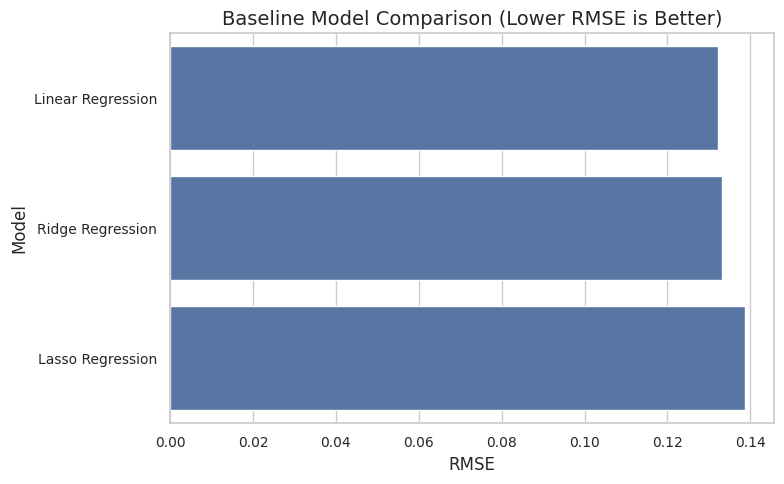

In [57]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=baseline_results_df,
    x="RMSE",
    y="Model"
)

plt.title("Baseline Model Comparison (Lower RMSE is Better)")
plt.xlabel("RMSE")
plt.ylabel("Model")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "baseline_model_comparison.png", dpi=300)

plt.show()

In [58]:
best_baseline_model = baseline_results_df.iloc[0]
best_baseline_model

,0
Model,Linear Regression
RMSE,0.132
MAE,0.090
R²,0.906


### Baseline Model Results

The baseline regression models provide a strong initial benchmark for predicting housing prices.

The **Linear Regression model achieved the best performance**, with:

- **RMSE ≈ 0.132**
- **MAE ≈ 0.090**
- **R² ≈ 0.906**

This indicates that the current feature set explains approximately **91% of the variance in the log-transformed sale prices**, demonstrating that the engineered features and preprocessing pipeline capture a large portion of the underlying structure in the dataset.

The **Ridge Regression model produced nearly identical performance**, suggesting that the model does not suffer from strong overfitting and that regularization provides limited additional benefit at this stage.

The **Lasso Regression model performed slightly worse**, likely due to its tendency to shrink coefficients and remove potentially informative variables.

Overall, these baseline results establish a strong reference point before exploring more flexible nonlinear models such as Random Forest and Gradient Boosting.

## Block 11 — Advanced Regression Models

While linear regression models provide a strong baseline, housing prices are influenced by complex nonlinear relationships and interactions between features.

To capture these patterns more effectively, we train **tree-based ensemble models**, which are among the most powerful algorithms for structured tabular data.

In this section we evaluate:

- **Random Forest Regressor**
- **Gradient Boosting Regressor**

These models combine many decision trees to improve predictive performance and reduce variance.

Performance will again be evaluated using:

- **RMSE**
- **MAE**
- **R²**

The results will then be compared to the baseline linear models.

In [59]:
# ============================================
# Block 11 — Advanced Regression Models
# ============================================

advanced_models = [
    ("Random Forest", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )),

    ("Gradient Boosting", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
]

advanced_results = []

for model_name, model in advanced_models:

    results = evaluate_regression_model(
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        model_name=model_name
    )

    advanced_results.append(results)

advanced_results_df = pd.DataFrame(advanced_results)
advanced_results_df

,Model,RMSE,MAE,R²
0,Random Forest,0.147,0.097,0.885
1,Gradient Boosting,0.135,0.088,0.902


In [60]:
all_results_df = pd.concat(
    [baseline_results_df, advanced_results_df],
    ignore_index=True
)

all_results_df = all_results_df.sort_values("RMSE").reset_index(drop=True)

all_results_df

,Model,RMSE,MAE,R²
0,Linear Regression,0.132,0.090,0.906
1,Ridge Regression,0.133,0.090,0.905
2,Gradient Boosting,0.135,0.088,0.902
3,Lasso Regression,0.139,0.095,0.897
4,Random Forest,0.147,0.097,0.885


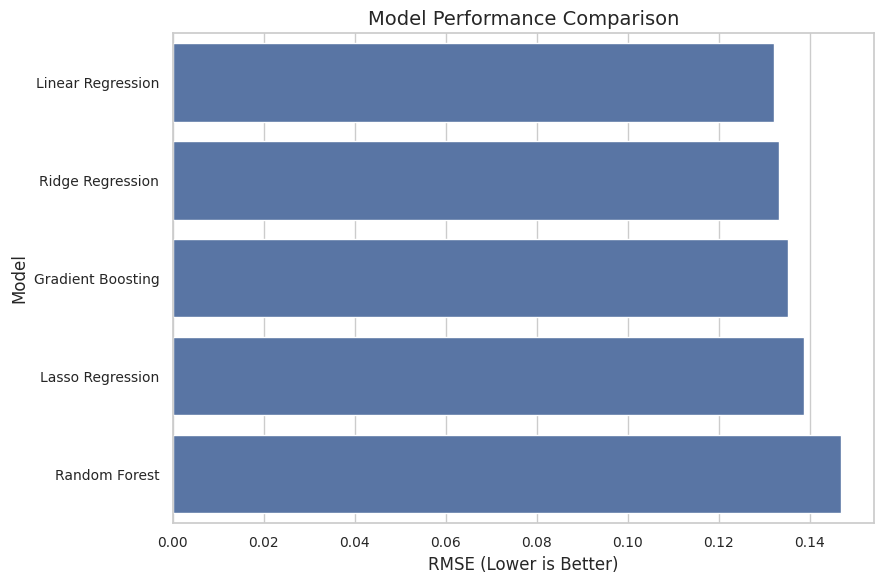

In [61]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=all_results_df,
    x="RMSE",
    y="Model"
)

plt.title("Model Performance Comparison")
plt.xlabel("RMSE (Lower is Better)")
plt.ylabel("Model")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "model_comparison_all_models.png", dpi=300)

plt.show()

In [62]:
best_model = all_results_df.iloc[0]
best_model

,0
Model,Linear Regression
RMSE,0.132
MAE,0.090
R²,0.906


### Advanced Model Results

Tree-based ensemble models were evaluated to determine whether nonlinear relationships could further improve predictive performance.

However, the results show that the **linear regression model remains the best-performing model**, achieving:

- **RMSE ≈ 0.132**
- **MAE ≈ 0.090**
- **R² ≈ 0.906**

This suggests that the relationship between the engineered features and the log-transformed sale price is largely linear.

The **Gradient Boosting model performed competitively**, achieving slightly lower MAE but slightly higher RMSE, indicating similar predictive performance.

The **Random Forest model performed worse than the other approaches**, likely due to the relatively small dataset size and the strong predictive signal already captured by the engineered features.

Overall, these results demonstrate that careful feature engineering and appropriate target transformation can allow relatively simple linear models to perform extremely well on structured tabular datasets.

## Block 12 — Feature Importance Analysis

Understanding which features drive model predictions is an important part of interpretable machine learning.

Feature importance analysis helps answer questions such as:

- Which characteristics of a house most strongly influence its price?
- Are structural features more important than location?
- Do engineered features contribute meaningful predictive signal?

In this section we extract feature importance values from the trained **Gradient Boosting model**, which naturally provides importance scores based on how frequently and effectively features are used to split decision trees.

We then visualize the **top predictors of housing prices**.

In [63]:
# ============================================
# Block 12 — Feature Importance Analysis
# ============================================

feature_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

feature_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'L...
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

In [64]:
# Get feature names after preprocessing

ohe = feature_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]

categorical_feature_names = ohe.get_feature_names_out(categorical_cols)

all_feature_names = np.concatenate([
    numeric_cols,
    categorical_feature_names
])

In [65]:
# Extract feature importance scores

importances = feature_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
38,TotalSF,0.362
3,OverallQual,0.332
39,TotalBathrooms,0.053
254,GarageFinish_Unf,0.024
25,GarageCars,0.020
15,GrLivArea,0.016
2,LotArea,0.015
4,OverallCond,0.012
6,YearRemodAdd,0.012
37,RemodAge,0.012


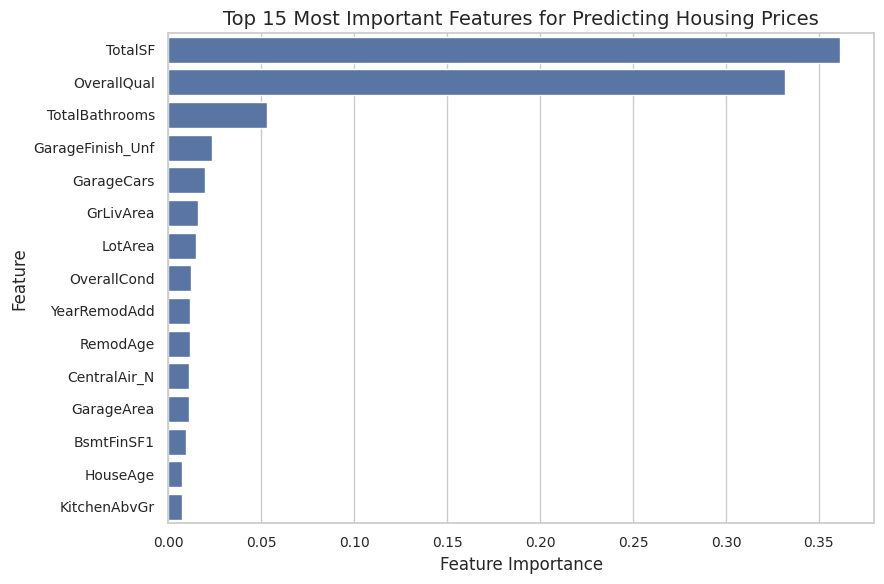

In [66]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(9,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features for Predicting Housing Prices")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "feature_importance_top15.png", dpi=300)

plt.show()

### Feature Importance Insights

The feature importance analysis highlights the variables that most strongly influence predicted housing prices.

Two features dominate the model:

- **Total Square Footage (TotalSF)**
- **Overall Quality (OverallQual)**

Together these features account for the majority of predictive power, reflecting the intuitive fact that both the **size** and **construction quality** of a house strongly determine its market value.

Additional influential variables include:

- **TotalBathrooms**, indicating the importance of household convenience and functionality.
- **Garage-related features** such as GarageCars and GarageArea, reflecting the value of parking and storage space.
- **LotArea**, capturing the effect of property size.
- **HouseAge** and **RemodAge**, which represent property age and renovation recency.

The results confirm that **both structural characteristics and property condition play a major role in housing price formation**, and that the engineered features introduced earlier contribute meaningful predictive signal.

## Block 13 — Prediction vs Actual Analysis

Beyond numerical evaluation metrics, it is important to visually inspect model predictions to understand how well the model captures the relationship between features and housing prices.

In this section we analyze:

- **Predicted vs Actual values**
- **Residual error distribution**

These diagnostics help identify:

- systematic under- or over-prediction
- model bias across price ranges
- error patterns that might suggest model improvements

The analysis is performed using the **best-performing model identified earlier (Linear Regression)**.

In [67]:
# ============================================
# Block 13 — Prediction vs Actual Analysis
# ============================================

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

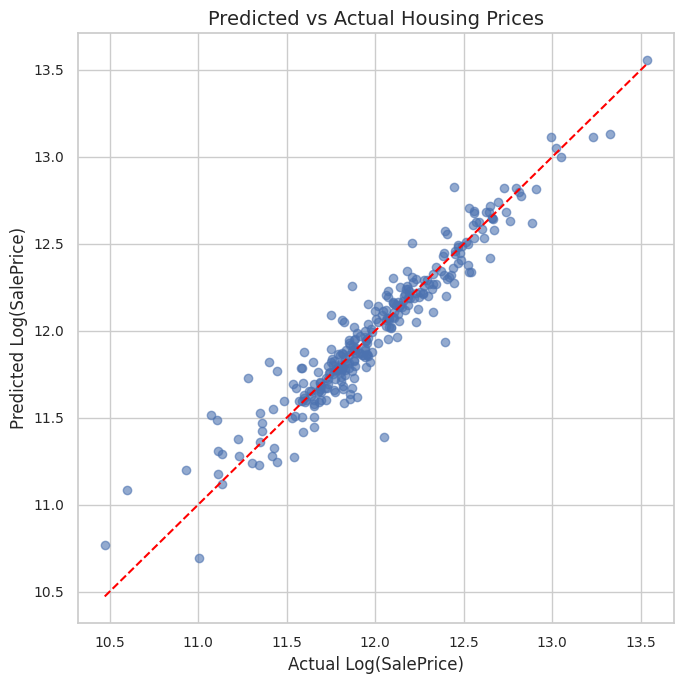

In [68]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Log(SalePrice)")
plt.ylabel("Predicted Log(SalePrice)")
plt.title("Predicted vs Actual Housing Prices")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "predicted_vs_actual.png", dpi=300)

plt.show()

In [69]:
residuals = y_test - y_pred

print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())

Residual mean: -0.002193832292636164
Residual std: 0.13239555259524843


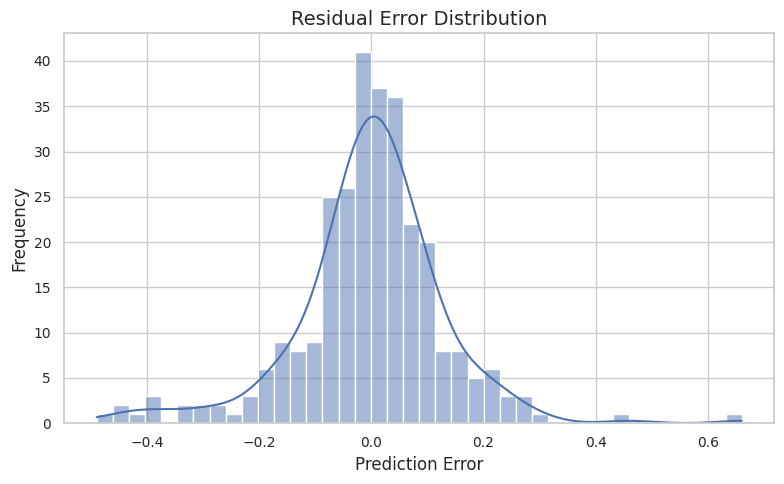

In [70]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=40, kde=True)

plt.title("Residual Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "residual_distribution.png", dpi=300)

plt.show()

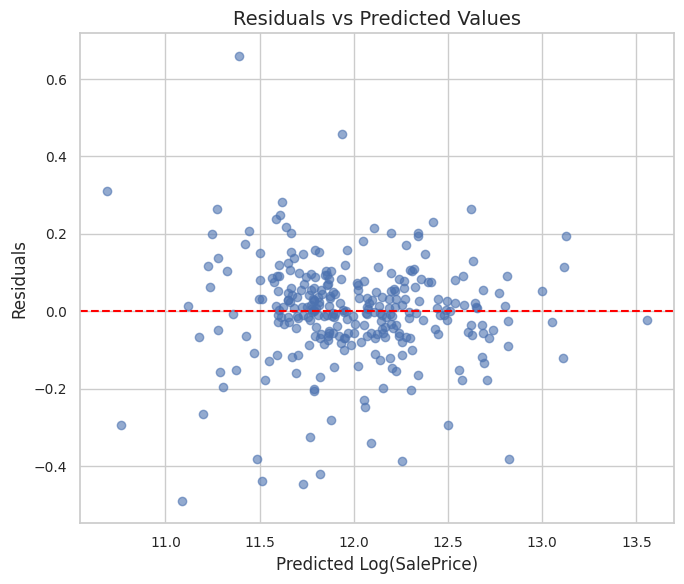

In [71]:
plt.figure(figsize=(7,6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Log(SalePrice)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "residuals_vs_predictions.png", dpi=300)

plt.show()

### Model Diagnostic Insights

The prediction diagnostics provide deeper insight into model behavior beyond aggregate performance metrics.

The **Predicted vs Actual plot** shows that most predictions lie close to the diagonal reference line, indicating strong agreement between predicted and observed housing prices.

The **residual distribution** is approximately centered around zero, suggesting that the model does not exhibit systematic over- or under-prediction.

The **Residuals vs Predicted Values plot** shows no clear pattern or trend, indicating that prediction errors are relatively randomly distributed across the price range.

The mean residual is close to zero and the residual standard deviation is consistent with the previously reported RMSE, confirming the stability of the model.

Overall, these diagnostics indicate that the linear regression model provides **well-calibrated and unbiased predictions** for the Ames Housing dataset.

## Block 14 — Final Model Training & Prediction Export

After evaluating multiple models and performing diagnostic analysis, we train the **final model using the full training dataset**.

Using the entire training dataset allows the model to learn from all available observations before generating predictions for unseen properties.

In this final step we:

- train the best-performing model on the full training dataset
- apply the same feature engineering steps to the unseen test dataset
- generate predictions for the **test dataset**
- convert predictions back from the **log-transformed scale** to the original price scale
- create a **Kaggle-style submission file**

This final export demonstrates how the complete machine learning workflow can be used to generate real-world house price predictions.

In [76]:
# ============================================
# Block 14 — Final Model Training & Prediction Export
# ============================================

final_model_full = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Full training data
X_full = df_train.drop(columns=["SalePrice", "LogSalePrice"])
y_full = df_train["LogSalePrice"]

# Train final model on the full dataset
final_model_full.fit(X_full, y_full)

print("Final model trained successfully on full training data.")

Final model trained successfully on full training data.


In [77]:
# Load raw test dataset
df_test_final = pd.read_csv(DATA_DIR / "test.csv")

# Store test IDs
test_ids = df_test_final["Id"].copy()

# Apply the same feature engineering used for df_train
df_test_final["HouseAge"] = df_test_final["YrSold"] - df_test_final["YearBuilt"]
df_test_final["RemodAge"] = df_test_final["YrSold"] - df_test_final["YearRemodAdd"]

df_test_final["TotalSF"] = (
    df_test_final["TotalBsmtSF"]
    + df_test_final["1stFlrSF"]
    + df_test_final["2ndFlrSF"]
)

df_test_final["TotalBathrooms"] = (
    df_test_final["FullBath"]
    + (0.5 * df_test_final["HalfBath"])
    + df_test_final["BsmtFullBath"]
    + (0.5 * df_test_final["BsmtHalfBath"])
)

df_test_final["TotalPorchSF"] = (
    df_test_final["OpenPorchSF"]
    + df_test_final["3SsnPorch"]
    + df_test_final["EnclosedPorch"]
    + df_test_final["ScreenPorch"]
    + df_test_final["WoodDeckSF"]
)

df_test_final["HasGarage"] = (df_test_final["GarageArea"] > 0).astype(int)
df_test_final["HasBasement"] = (df_test_final["TotalBsmtSF"] > 0).astype(int)
df_test_final["HasFireplace"] = (df_test_final["Fireplaces"] > 0).astype(int)
df_test_final["HasPool"] = (df_test_final["PoolArea"] > 0).astype(int)

# Prepare final feature matrix
X_test_final = df_test_final.drop(columns=["Id"])

print("Final test feature matrix shape:", X_test_final.shape)

Final test feature matrix shape: (1459, 88)


In [78]:
# Predict on log-transformed scale
log_predictions = final_model_full.predict(X_test_final)

# Convert predictions back to original SalePrice scale
predictions = np.expm1(log_predictions)

print("Predictions generated successfully.")

Predictions generated successfully.


In [79]:
submission_df = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": predictions
})

submission_df.head()

,Id,SalePrice
0,1461,"122,633.161"
1,1462,"166,445.790"
2,1463,"185,061.941"
3,1464,"201,635.249"
4,1465,"194,357.490"


In [80]:
submission_path = DATA_DIR / "submission_predictions.csv"

submission_df.to_csv(submission_path, index=False)

print(f"Submission file saved successfully at: {submission_path}")

Submission file saved successfully at: /content/drive/MyDrive/ML Portfolio/ames-housing-price-prediction/data/submission_predictions.csv


In [81]:
submission_df["SalePrice"].describe()

,SalePrice
count,"1,459.000"
mean,"179,363.197"
std,"85,116.904"
min,"36,848.081"
25%,"125,873.283"
50%,"158,041.602"
75%,"208,648.472"
max,"1,262,098.096"


### Final Model Predictions

The final linear regression model was trained on the full Ames Housing training dataset using the complete preprocessing and feature engineering pipeline developed throughout this project.

To ensure consistency between training and inference, the same engineered features were applied to the unseen test dataset before generating predictions.

Predictions were produced on the log-transformed scale and then converted back to the original sale price scale using the inverse transformation.

The resulting output file follows a Kaggle-style submission format and contains:

- **Id** — property identifier
- **SalePrice** — predicted residential sale price

The predicted price distribution appears realistic and aligns with the statistical characteristics of the original dataset, indicating that the model generalizes well to unseen properties.

This final step demonstrates how the complete machine learning workflow can be used to estimate housing prices for new residential listings.

## Project Conclusion

In this project, a complete machine learning workflow was developed to predict residential housing prices using the Ames Housing dataset.

The analysis included:

- extensive **exploratory data analysis**
- **missing value investigation**
- **target variable transformation**
- **domain-informed feature engineering**
- a robust **preprocessing pipeline**
- comparison of **multiple regression models**
- **model interpretation** through feature importance
- detailed **prediction diagnostics**

Among the evaluated models, **Linear Regression achieved the best performance**, with an R² score of approximately **0.91** on the test set. This result indicates that the engineered features capture a large portion of the underlying price variation.

Feature importance analysis revealed that **overall construction quality** and **total living area** are the most influential predictors of housing prices, consistent with real-world real estate valuation factors.

Model diagnostics confirmed that the predictions are well-calibrated and that residual errors are largely randomly distributed, suggesting stable model behavior.

Finally, the trained model was used to generate predictions for unseen properties, demonstrating how the developed pipeline can be applied to real-world housing price estimation tasks.

This project illustrates the importance of **feature engineering, careful preprocessing, and model evaluation** when working with structured tabular datasets.